Saving lena.jpg to lena.jpg


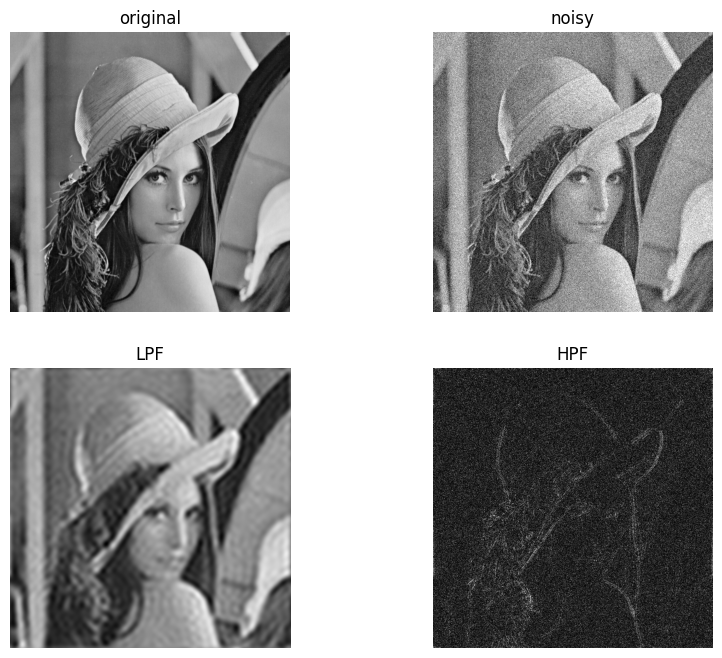

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = cv2.imread(filename, 0)

noise = np.random.normal(0, 25, img.shape)
noisy = np.clip(img.astype(np.float64) + noise, 0, 255).astype(np.uint8)

f = np.fft.fft2(noisy)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
mask = np.zeros((rows, cols))
mask[crow - 30 : crow + 30, ccol - 30 : ccol + 30] = 1

lpf_shift = fshift * mask
hpf_shift = fshift * (1 - mask)

lpf_ishift = np.fft.ifftshift(lpf_shift)
lpf = np.abs(np.fft.ifft2(lpf_ishift))

hpf_ishift = np.fft.ifftshift(hpf_shift)
hpf = np.abs(np.fft.ifft2(hpf_ishift))

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(noisy, cmap="gray")
plt.title("noisy")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(lpf, cmap="gray")
plt.title("LPF")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(hpf, cmap="gray")
plt.title("HPF")
plt.axis("off")

plt.show()